## Setup

In [1]:
from pathlib import Path
from tempfile import mkdtemp
from shutil import rmtree
import sys

sys.path.append('..')
from utils import (
    draw_pr_curve_from_cv_results,
    print_cv_results,
    cv_results_to_long
)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.regression.distance_based import KNeighborsTimeSeriesRegressor
from sklearn.model_selection import (GridSearchCV,
                                     cross_validate,
                                     cross_val_predict,
                                     StratifiedKFold,
                                     TunedThresholdClassifierCV)
from sklearn.metrics import PredictionErrorDisplay
from aeon.transformations.collection import Normalizer
from sklearn.pipeline import Pipeline
from aeon.distances import dtw_distance

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
cachedir = mkdtemp()

In [6]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

Define dtw distances with different constraints for hyperparameter tuning.

In [7]:
def dtw005(x, y):
    return dtw_distance(x, y, window=.05)

def dtw01(x, y):
    return dtw_distance(x, y, window=.1)

In [8]:
def plot_results(results):
    results['param_clf__distance'] = results['param_clf__distance'].map(
    lambda x: f'dtw (window=0.{str(x).split()[1][4:]})' if str(x).startswith('<') else x
        )
    sns.relplot(results, x='param_clf__n_neighbors', y='test_score',
                errorbar='sd',
                col='param_clf__distance', hue='param_clf__weights',
                kind='line')

In [9]:
ks = np.arange(1, 60, 4)

param_grid = {'clf__distance': ('euclidean', dtw005, dtw01),
    'clf__n_neighbors': ks,
    'clf__weights': ('uniform', 'distance')
    }

In [10]:
pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('clf', KNeighborsTimeSeriesClassifier())],
    memory=cachedir
)

In [11]:
grid_cv = StratifiedKFold(shuffle=False)
cv = StratifiedKFold(shuffle=True, random_state=42)

## Shape based classification and regression with KNN

### Action

In [12]:
train_y = train['action']
train_y.shape

(850,)

In [13]:
grid = GridSearchCV(
    pipeline, param_grid=param_grid,
    scoring='average_precision', n_jobs=-1, verbose=2,
    cv=grid_cv
)

In [14]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.4s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.4s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.4s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.5s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.4s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.4s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.3s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=5, clf__weights=uniform; to

,estimator,Pipeline(memo...lassifier())])
,param_grid,"{'clf__distance': ('euclidean', ...), 'clf__n_neighbors': array([ 1, 5..., 49, 53, 57]), 'clf__weights': ('uniform', ...)}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,distance,'euclidean'


In [15]:
print(grid.best_score_)
print(grid.best_params_)

0.6198063877381761
{'clf__distance': 'euclidean', 'clf__n_neighbors': np.int64(21), 'clf__weights': 'distance'}


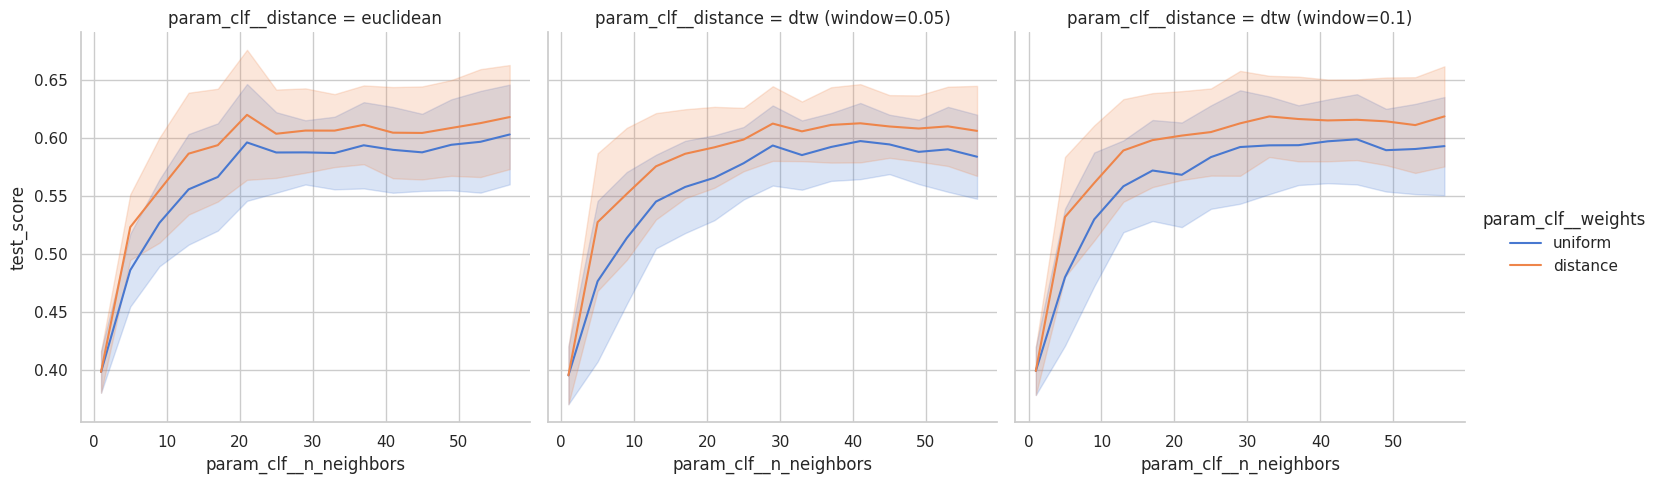

In [16]:
plot_results(cv_results_to_long(grid.cv_results_))

Generally speaking, impact of the distance function and of Sakoe Chiba band window size is negligible, especially considering the score variance across folds.
Performance of the model plateaus around 20 neighbors.

In [17]:
cv_results = cross_validate(grid.best_estimator_, train_X, train_y, n_jobs=-1,
                            scoring=('f1', 'precision', 'recall', 'average_precision'),
                            cv=cv, return_estimator=True, return_indices=True)

In [18]:
print_cv_results(cv_results)

f1: 0.54 (0.02)
precision: 0.56 (0.02)
recall: 0.52 (0.04)
average_precision: 0.58 (0.03)


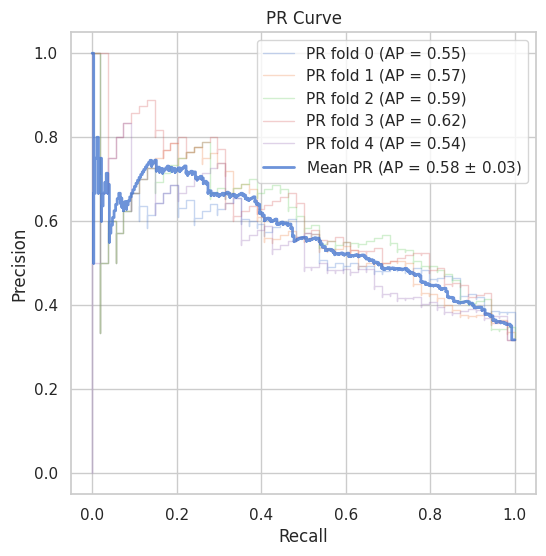

In [19]:
draw_pr_curve_from_cv_results(cv_results, train_X, train_y)

We tune the decision threshold for the classifier for the best F1 score of hte positive class.

In [20]:
action_knn = TunedThresholdClassifierCV(grid.best_estimator_, scoring='f1')
action_knn.fit(train_X, train_y)

,estimator,Pipeline(memo...'distance'))])
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,distance,'euclidean'
,distance_params,None


In [22]:
print("Best threshold:", action_knn.best_threshold_)
print("Best F1:", action_knn.best_score_)

Best threshold: 0.4140577713077508
Best F1: 0.5926679887052746


### Rating Category

In [23]:
train_y = train['rating_category']

In [24]:
# Use macro f1 for multiclass classification
grid.scoring = 'f1_macro'

In [25]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__distance=euclidean, clf__n_neighbors=1, clf__weights=distance; to

,estimator,Pipeline(memo...lassifier())])
,param_grid,"{'clf__distance': ('euclidean', ...), 'clf__n_neighbors': array([ 1, 5..., 49, 53, 57]), 'clf__weights': ('uniform', ...)}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,distance,<function dtw...x7f770f63e520>


In [26]:
print(grid.best_score_)
print(grid.best_params_)

0.2679143016714525
{'clf__distance': <function dtw01 at 0x7f770f63e520>, 'clf__n_neighbors': np.int64(9), 'clf__weights': 'distance'}


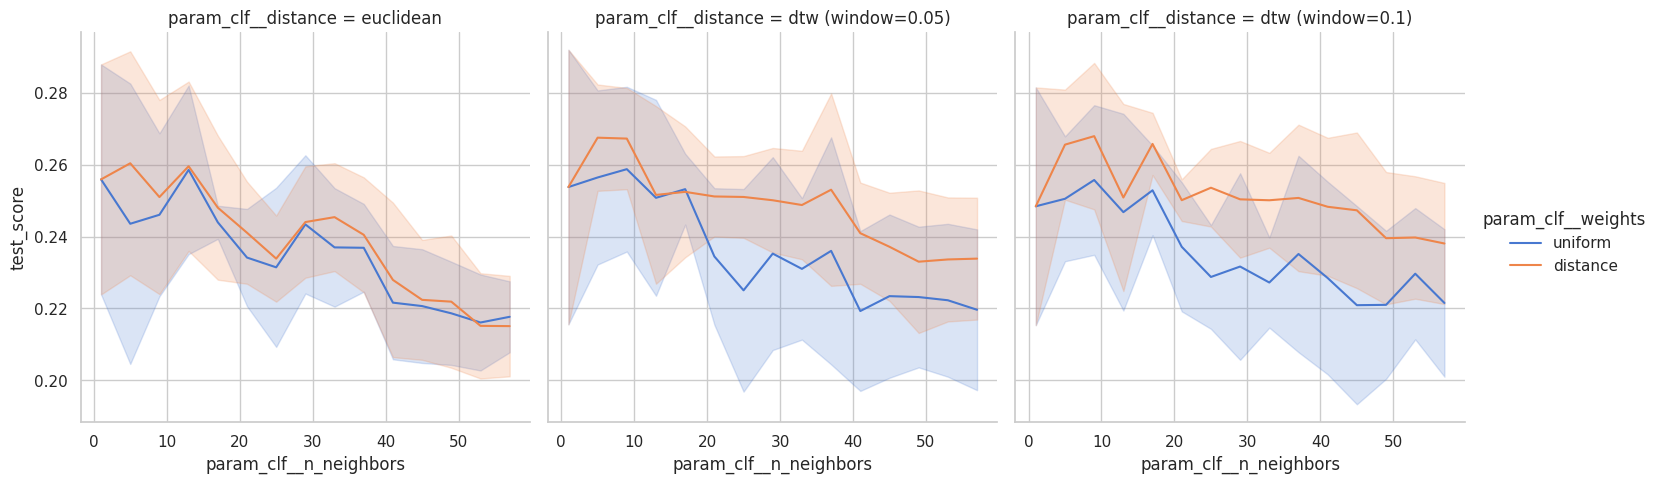

In [27]:
plot_results(cv_results_to_long(grid.cv_results_))

We choose a model with less variance.

In [28]:
rating_knn = KNeighborsTimeSeriesClassifier(
    distance=dtw01,
    n_neighbors=17,
    weights='distance'
)

In [29]:
cv_results = cross_validate(rating_knn, train_X, train_y, n_jobs=-1, cv=cv,
                            scoring=('f1_macro', 'accuracy', 'precision_macro', 'recall_macro'))

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [30]:
print_cv_results(cv_results)

f1_macro: 0.27 (0.02)
accuracy: 0.43 (0.03)
precision_macro: 0.33 (0.06)
recall_macro: 0.28 (0.02)


### Rating (regression)

In [31]:
pipeline = Pipeline([
    ('scaler', Normalizer()),
    ('regressor', KNeighborsTimeSeriesRegressor())
])

In [32]:
regressor_param_grid = {
    key.replace('clf', 'regressor'): value
    for key, value
    in param_grid.items()
}

In [33]:
train_y = train['rating']
grid = GridSearchCV(
    pipeline, param_grid=regressor_param_grid,
    scoring='r2', n_jobs=-1, verbose=2,
)

In [34]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__distance=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__distance=eu

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__distance': ('euclidean', ...), 'regressor__n_neighbors': array([ 1, 5..., 49, 53, 57]), 'regressor__weights': ('uniform', ...)}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,distance,<function dtw...x7f770f63e480>


In [35]:
print(grid.best_score_)
print(grid.best_params_)

0.20413492569430777
{'regressor__distance': <function dtw005 at 0x7f770f63e480>, 'regressor__n_neighbors': np.int64(29), 'regressor__weights': 'distance'}


In [36]:
train['rating'].var()

np.float64(0.8154520889627935)

Sum of square error is in fact smaller that the sample variance of the target variable, so the regressor is doing better than predicting the mean.

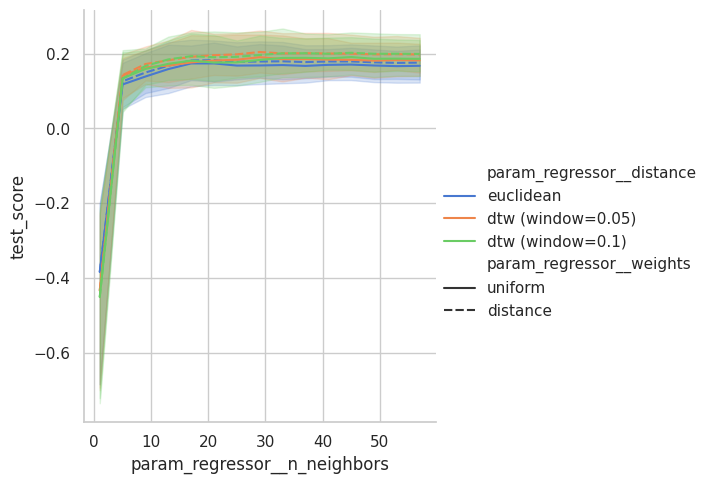

In [37]:
results = cv_results_to_long(grid.cv_results_)

results['param_regressor__distance'] = results['param_regressor__distance'].map(
lambda x: f'dtw (window=0.{str(x).split()[1][4:]})' if str(x).startswith('<') else x
    )
sns.relplot(results, x='param_regressor__n_neighbors', y='test_score',
        hue='param_regressor__distance', style='param_regressor__weights',
        kind='line')

Performance of the model plateaus around 10 neighbors and has no sensibility to distance and weights parameters, so we choose a simpler configuration.

In [38]:
regressor_knn = grid.best_estimator_.set_params(
    regressor__n_neighbors=10,
    regressor__distance='euclidean',
    regressor__weights='uniform'
)
regressor_knn

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,distance,'euclidean'
,distance_params,None
,n_neighbors,10
,weights,'uniform'
,n_jobs,1


In [39]:
cv_results = cross_validate(regressor_knn, train_X, train_y, n_jobs=-1,
                            scoring=('neg_mean_squared_error', 'r2'))

In [40]:
print_cv_results(cv_results)

neg_mean_squared_error: -0.69 (0.11)
r2: 0.14 (0.07)


In [41]:
y_pred = cross_val_predict(regressor_knn, train_X, train_y, n_jobs=-1)

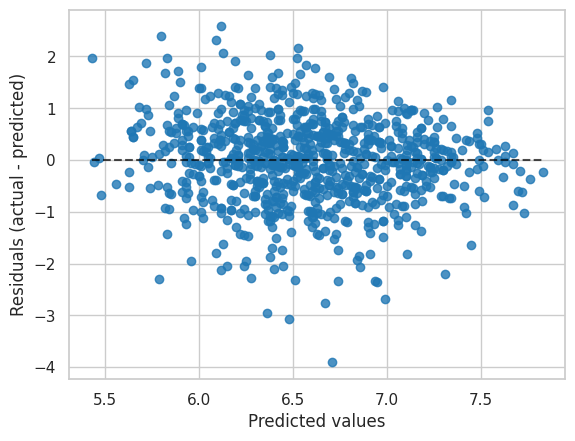

In [42]:
PredictionErrorDisplay.from_predictions(train_y, y_pred)

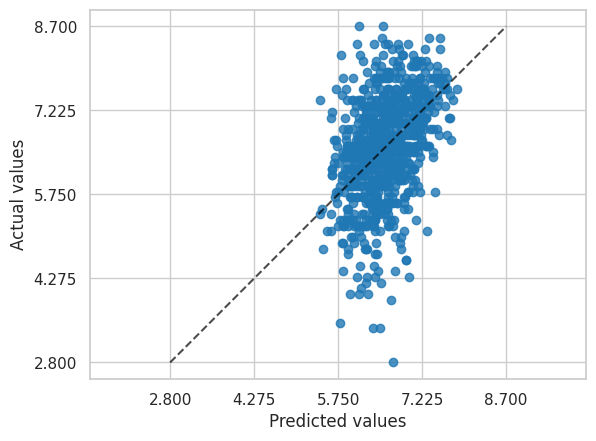

In [43]:
PredictionErrorDisplay.from_predictions(train_y, y_pred, kind='actual_vs_predicted')

## Tear Down

In [44]:
try:
    rmtree(cachedir)
except FileNotFoundError:
    pass